# Histogram and Pie chart for ML interest

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def parse_scale(val):
    if pd.isna(val):
        return np.nan
    s = str(val)
    m = re.match(r"\s*(\d+)\s*-\s*(\d+)", s)
    if m:
        return (int(m.group(1)) + int(m.group(2))) / 2
    m = re.search(r"\d+(\.\d+)?", s)
    return float(m.group()) if m else np.nan

short_names = ["LaTeX skill", "Python skill", "ML interest", "Teamwork interest"]
df = pd.read_csv("survey.csv")
scale_cols = [c for c in df.columns if "Scale of 1 to 10" in c]
scales = df[scale_cols].apply(lambda col: col.map(parse_scale))
scales.columns = short_names

colors = ["#5787D5", "#EDA848", "#27A9E1", "#A02DF2"]

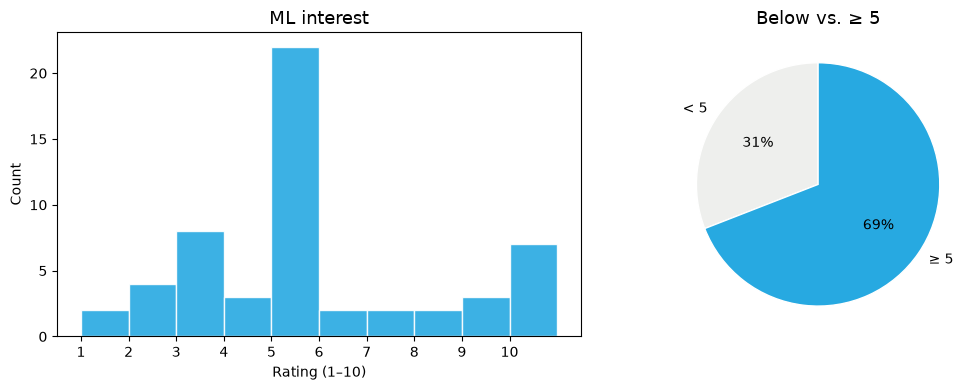

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(scales["ML interest"], bins=range(1, 12), color="#27A9E1", edgecolor="white", alpha=0.9)
ax1.set_title("ML interest", fontsize=13)
ax1.set_xlabel("Rating (1\u201310)")
ax1.set_ylabel("Count")
ax1.set_xticks(range(1, 11))

below = (scales["ML interest"] < 5).sum()
above = (scales["ML interest"] >= 5).sum()
ax2.pie([below, above], labels=["< 5", "\u2265 5"], colors=["#EEEFED", "#27A9E1"],
        autopct="%1.0f%%", startangle=90, wedgeprops={"edgecolor": "white"})
ax2.set_title("Below vs. \u2265 5", fontsize=13)

fig.tight_layout()
plt.show()